In [24]:
import numpy as np
import pandas as pd
from pycirclize import Circos

In [25]:
r_pancreas = pd.read_csv("ligands_receptors/pancreas_ht224p1/receiver_mean.csv")
s_pancreas = pd.read_csv("ligands_receptors/pancreas_ht224p1/sender_mean.csv")

r_sein = pd.read_csv("ligands_receptors/sein_ht425b1/receiver_mean.csv")
s_sein = pd.read_csv("ligands_receptors/sein_ht425b1/sender_mean.csv")

# Pancreas

In [26]:
r_pancreas.drop(7, inplace=True)

In [27]:
s_pancreas.drop(7, inplace=True)

In [28]:
s_pancreas.columns

Index(['cell_type', 's-PLG-F2R', 's-PLG-F2RL3', 's-PLG-PARD3', 's-PLG-F2RL1',
       's-PLG-F2RL2', 's-UCN2-CRHR1', 's-UCN2-CRHR2', 's-IL9-IL9R_IL2RG',
       's-FSHB-FSHR',
       ...
       's-INSL3-RXFP1', 's-INSL3-RXFP3', 's-INSL3-RXFP2', 's-INSL3-RXFP4',
       's-APLN-APLNR', 's-IAPP-CALCR', 's-IAPP-CALCRL',
       's-INHBA-ACVR1B_ACVR2B', 's-INHBA-ACVR1B_ACVR2A', 's-total-total'],
      dtype='object', length=1196)

In [29]:
n = len(s_pancreas)

In [30]:
matrix_pancreas = np.zeros((n,n))

for name_sender in s_pancreas.columns[1:] :
    l_sender = list(s_pancreas[name_sender])
    l_receiver = list(r_pancreas['r-' + name_sender[2:]])

    for i in range(n):
        for j in range(n):
            matrix_pancreas[i][j] += min(l_sender[i], l_receiver[j])
            

In [31]:
s_pancreas['cell_type']

0                ADM
1            B-cells
2       Ductal-like1
3       Ductal-like2
4        Endothelial
5        Fibroblasts
6             Islets
8        Macrophages
9               Mast
10    Other_doublets
11            Plasma
12           T-cells
13             Tumor
Name: cell_type, dtype: object

In [49]:
df_pancreas = pd.DataFrame(matrix_pancreas, index = list(s_pancreas['cell_type']), columns = list(s_pancreas['cell_type']))

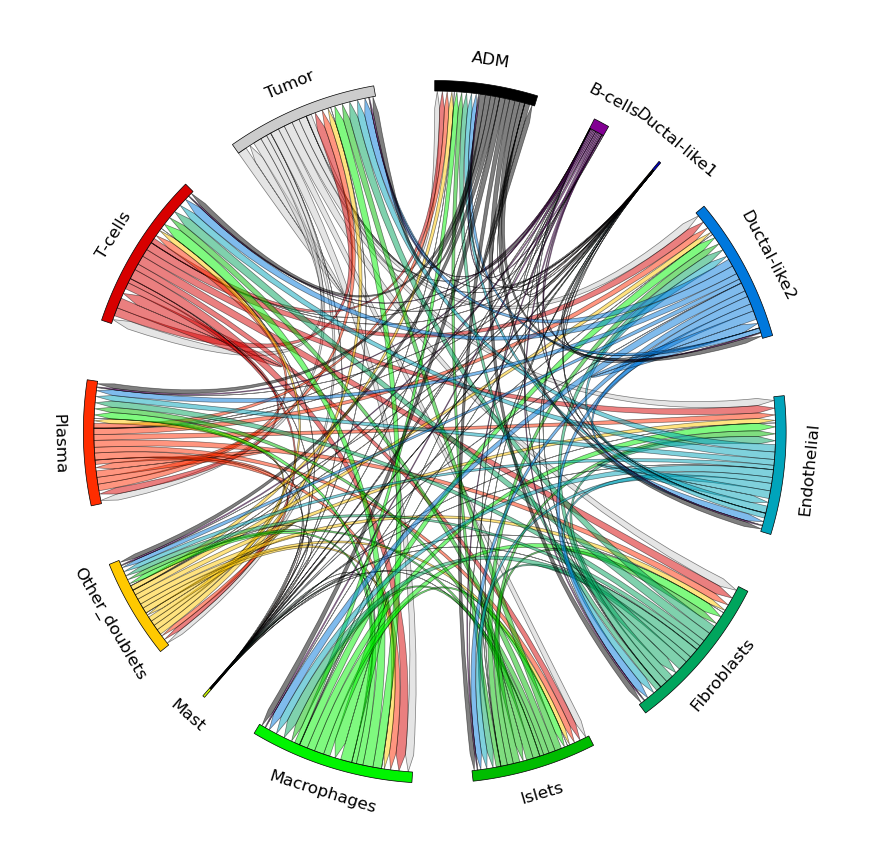

In [33]:
circos = Circos.chord_diagram(
    df_pancreas,
    space=10,
    cmap="nipy_spectral",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

fig = circos.plotfig()

# Sein

In [34]:
r_sein.drop(7, inplace=True)

In [35]:
s_sein.drop(7, inplace=True)

In [36]:
s_sein.columns

Index(['cell_type', 's-LHB-LHCGR', 's-IL36A-IL1RL2_IL1RAP', 's-C5-C5AR1',
       's-TNFSF13-TNFRSF13B', 's-TNFSF13-TNFRSF17', 's-RARRES2-GPR1',
       's-RARRES2-CMKLR1', 's-HBEGF-ERBB4', 's-HBEGF-ERBB2_ERBB4',
       ...
       's-FGF17-FGFR4', 's-FGF17-FGFR3', 's-PRL-PRLR', 's-IL6-IL6R_IL6ST',
       's-NRG4-ERBB4', 's-NRG4-ERBB2_ERBB4', 's-CCL15-CCR1', 's-EPO-EPOR',
       's-APLN-APLNR', 's-total-total'],
      dtype='object', length=1196)

In [37]:
n = len(s_sein)

In [38]:
matrix_sein = np.zeros((n,n))

for name_sender in s_sein.columns[1:] :
    l_sender = list(s_sein[name_sender])
    l_receiver = list(r_sein['r-' + name_sender[2:]])

    for i in range(n):
        for j in range(n):
            matrix_sein[i][j] += min(l_sender[i], l_receiver[j])
            

In [39]:
s_sein['cell_type']

0       Adipocyte
1               B
2           Basal
3     Endothelial
4      Fibroblast
5           LumHR
6          LumSec
8        Pericyte
9          Plasma
10              T
11          Tumor
Name: cell_type, dtype: object

In [46]:
df_sein = pd.DataFrame(matrix_sein, index = list(s_sein['cell_type']), columns = list(s_sein['cell_type']))
df_sein

,Adipocyte,B,Basal,Endothelial,Fibroblast,LumHR,LumSec,Pericyte,Plasma,T,Tumor
Adipocyte,0.156171,0.156171,0.208228,1.396412,1.396412,0.312343,0.156171,0.156171,1.396412,1.396412,1.396412
B,0.156171,0.156171,0.208228,1.396412,1.396412,0.312343,0.156171,0.156171,1.396412,1.396412,1.396412
Basal,0.156171,0.156171,0.208228,1.861883,1.861883,0.312343,0.156171,0.156171,1.861883,1.861883,1.861883
Endothelial,0.265974,0.265974,0.350734,79.296831,74.635574,0.520253,0.265974,0.265974,60.442528,70.679831,75.278784
Fibroblast,0.261499,0.261499,0.346258,76.706361,82.770541,0.515777,0.261499,0.261499,60.441915,71.088626,78.120501
LumHR,0.001207,0.001207,0.001207,0.002414,0.002414,0.001207,0.001207,0.001207,0.002414,0.002414,0.002414
LumSec,0.156171,0.156171,0.208228,1.396412,1.396412,0.312343,0.156171,0.156171,1.396412,1.396412,1.396412
Pericyte,0.156171,0.156171,0.208228,1.396412,1.396412,0.312343,0.156171,0.156171,1.396412,1.396412,1.396412
Plasma,0.254278,0.254278,0.339038,60.874787,59.884772,0.508557,0.254278,0.254278,60.375340,56.610749,60.592364
T,0.254278,0.254278,0.339038,77.234579,68.682298,0.508557,0.254278,0.254278,56.046063,109.294901,75.649367


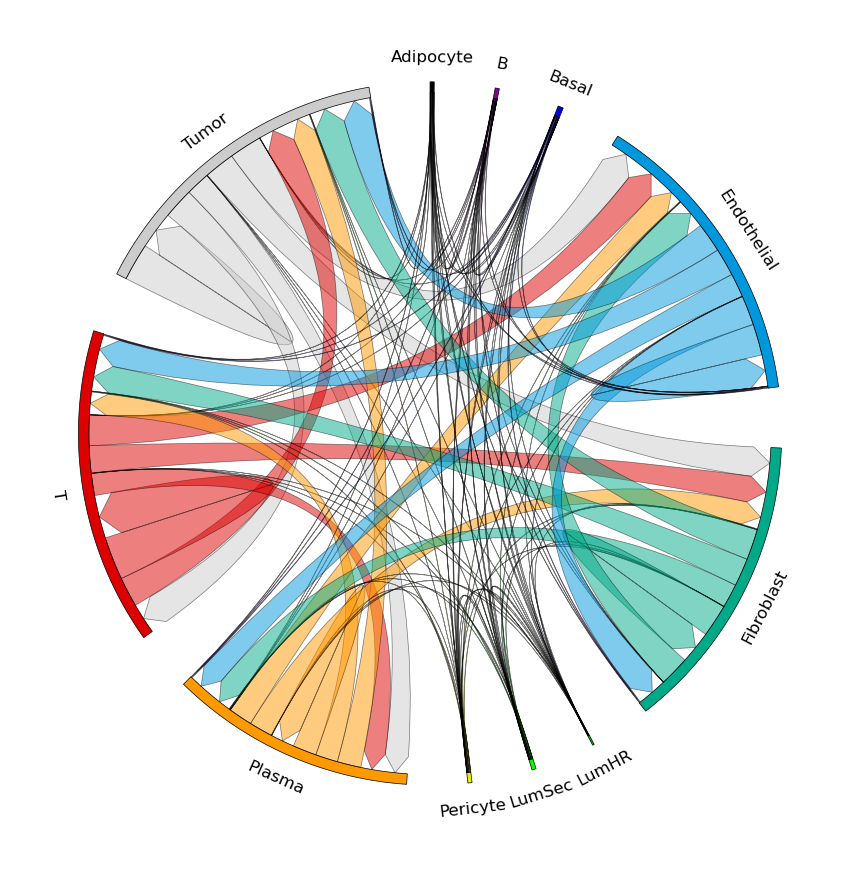

In [50]:
circos = Circos.chord_diagram(
    df_sein,
    space=10,
    cmap="nipy_spectral",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

fig = circos.plotfig()

# Centrality comparaison

## Centrality de la tumeur vis-à-vis des cellules immunitaires

## Micro-environnement tumoral